In [ ]:

import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/02_nav_history.csv")

df.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [ ]:
df.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [ ]:
df['return'] = df['nav'].pct_change()

VaR = df['return'].quantile(0.05)

CVaR = df[df['return'] <= VaR]['return'].mean()

print("Historical VaR:", VaR)
print("CVaR:", CVaR)

Historical VaR: -0.016321530360663104
CVaR: -0.029753624373512297


In [ ]:
df['rolling_mean'] = df['return'].rolling(90).mean()

df['rolling_std'] = df['return'].rolling(90).std()

df['Sharpe'] = (df['rolling_mean'] / df['rolling_std']) * np.sqrt(252)

df[['date','Sharpe']]

,date,Sharpe
0,2022-01-03,NaN
1,2022-01-04,NaN
2,2022-01-05,NaN
3,2022-01-06,NaN
4,2022-01-07,NaN
...,...,...
45995,2026-05-25,2.042795
45996,2026-05-26,2.064950
45997,2026-05-27,1.952646
45998,2026-05-28,1.406239


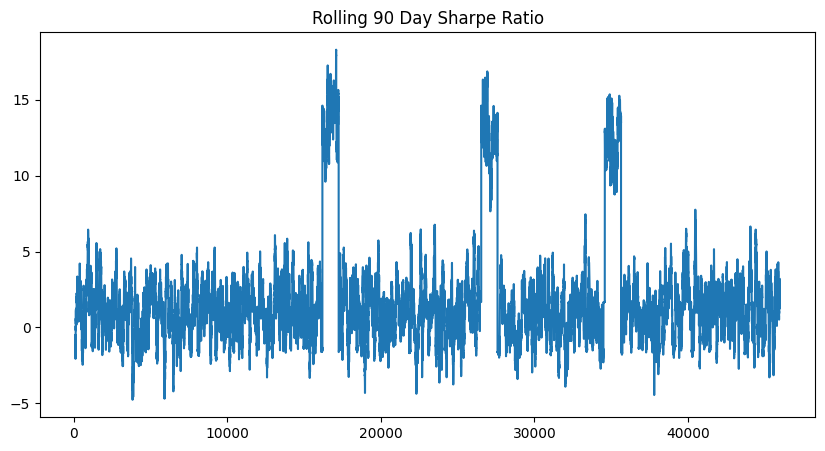

In [ ]:
import matplotlib.pyplot as plt

df['Sharpe'].plot(figsize=(10,5))
plt.title("Rolling 90 Day Sharpe Ratio")
plt.savefig("rolling_sharpe_chart.png")

In [ ]:
import pandas as pd

df = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

print(df.columns)

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


In [ ]:
print(df.head())

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  


In [ ]:
import pandas as pd

df = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

df['month'] = pd.to_datetime(df['month'])

df = df.sort_values('month')

df['gap_days'] = df['month'].diff().dt.days

at_risk = df[df['gap_days'] > 35]

print(at_risk)

Empty DataFrame
Columns: [month, sip_inflow_crore, active_sip_accounts_crore, new_sip_accounts_lakh, sip_aum_lakh_crore, yoy_growth_pct, gap_days]
Index: []


In [26]:
df = pd.read_csv("../data/raw/07_scheme_performance.csv")

print(df.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


In [27]:
import pandas as pd

df = pd.read_csv("../data/raw/07_scheme_performance.csv")

df['sharpe_ratio'] = pd.to_numeric(df['sharpe_ratio'], errors='coerce')

recommended = df[df['risk_grade'].str.lower() == "low"]

top_funds = recommended.sort_values(
    by="sharpe_ratio",
    ascending=False
).head(3)

print(top_funds[['scheme_name','risk_grade','sharpe_ratio']])

                                 scheme_name risk_grade  sharpe_ratio
14  ICICI Pru Liquid Fund - Regular - Growth        Low          7.68
23      Kotak Liquid Fund - Regular - Growth        Low          6.18
30       ABSL Liquid Fund - Regular - Growth        Low          5.14


In [28]:
import pandas as pd

df = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print(df.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [29]:
import pandas as pd

df = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

# convert weight percentage to decimal
df['weight'] = df['weight_pct'] / 100

# HHI calculation per fund
hhi = df.groupby('amfi_code')['weight'].apply(
    lambda x: (x**2).sum()
)

print(hhi)

amfi_code
100016    0.139534
100033    0.147592
101206    0.129332
101207    0.200700
102885    0.174709
102886    0.114693
102887    0.129805
118632    0.168298
118633    0.121461
118634    0.108358
118635    0.135944
119092    0.206448
119093    0.130894
119094    0.136406
119095    0.109605
119551    0.118716
119552    0.108011
119598    0.107349
119599    0.174751
120503    0.140870
120504    0.108674
120505    0.157570
120506    0.153794
120841    0.149680
120842    0.127439
120843    0.128683
125497    0.136586
125498    0.152414
148567    0.138584
148568    0.167930
148569    0.149396
149322    0.134398
149323    0.141621
149324    0.118677
Name: weight, dtype: float64


In [30]:
for value in hhi:
    if value > 0.25:
        print("High concentration")
    else:
        print("Diversified portfolio")

Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
Diversified portfolio
